# Deliverable 3 / Task 1 - Data Preprocessing & UNet Baseline

1. Interpolation at 256 px: nearest vs bilinear. The winner is used everywhere later.
2. Augmentation ablation at 256 px using the winning interpolation.
3. Learning-rate / batch-size comparison using the winning interpolation and augmentation.
4. Resolution comparison, 256 vs 384, using the best fixed pipeline.

Before each run, the notebook checks for an exact saved metrics JSON first, then for a matching checkpoint/history pair. Existing runs are loaded and skipped. All training runs use 8 epochs.

## 1 - Local Setup


In [1]:
from pathlib import Path
import os, gc, json, pickle, random, shutil, time

import cv2
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

PROJECT_ROOT = Path.cwd().resolve()
SOURCE_ROOT = PROJECT_ROOT / 'preprocessed_data' / 'preprocessed_data'
VARIANT_ROOT = PROJECT_ROOT / 'preprocessed_data' / 'resized_variants'
RUNS_ROOT = PROJECT_ROOT / 'runs' / 'd1_unet'
FIG_ROOT = RUNS_ROOT / 'figures'
CKPT_ROOT = RUNS_ROOT / 'checkpoints'
HIST_ROOT = RUNS_ROOT / 'histories'
METRIC_ROOT = RUNS_ROOT / 'metrics'

for p in [VARIANT_ROOT, RUNS_ROOT, FIG_ROOT, CKPT_ROOT, HIST_ROOT, METRIC_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
if DEVICE == 'cuda':
    torch.backends.cudnn.benchmark = True
    print(f'Device : {torch.cuda.get_device_name(0)}')
    print(f'CUDA   : {torch.version.cuda}')
else:
    print('Device : CPU')

# Windows notebook execution is more reliable with single-process data loading.
NUM_WORKERS = 0 if os.name == 'nt' else 2
print(f'Project root : {PROJECT_ROOT}')
print(f'Data root    : {SOURCE_ROOT}')
print(f'Runs root    : {RUNS_ROOT}')
print(f'Workers      : {NUM_WORKERS}')

assert SOURCE_ROOT.exists(), f'Missing data root: {SOURCE_ROOT}'
assert (SOURCE_ROOT / 'image').exists(), 'Missing image folder'
assert (SOURCE_ROOT / 'depth').exists(), 'Missing depth folder'


Device : NVIDIA GeForce RTX 4070
CUDA   : 12.1
Project root : C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation
Data root    : C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\preprocessed_data\preprocessed_data
Runs root    : C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d1_unet
Workers      : 0


## 2 - Dataset Sanity Checks


In [2]:
def read_list(path):
    with open(path, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f if line.strip()]

train_list = read_list(SOURCE_ROOT / 'train.txt')
val_list = read_list(SOURCE_ROOT / 'validation.txt')
test_list = read_list(SOURCE_ROOT / 'test.txt')
all_list = train_list + val_list + test_list

print(f'Train : {len(train_list)}')
print(f'Val   : {len(val_list)}')
print(f'Test  : {len(test_list)}')
print(f'Total : {len(all_list)}')
print(f'First 5 names: {all_list[:5]}')

missing = []
for name in all_list:
    if not (SOURCE_ROOT / 'image' / f'{name}.jpg').exists() or not (SOURCE_ROOT / 'depth' / f'{name}.npy').exists():
        missing.append(name)
print(f'Missing image/depth pairs: {len(missing)}')
assert not missing, missing[:10]

for split_name, split in [('train', train_list), ('validation', val_list), ('test', test_list)]:
    folders = sorted({name.split('_')[0] for name in split})
    print(f'{split_name:10s}: folders {folders[0]} to {folders[-1]} ({len(folders)} folders)')


Train : 30325
Val   : 3283
Test  : 2827
Total : 36435
First 5 names: ['00001_0', '00001_1', '00001_2', '00001_3', '00001_4']
Missing image/depth pairs: 0
train     : folders 00001 to 00152 (127 folders)
validation: folders 00153 to 00168 (16 folders)
test      : folders 00169 to 00185 (16 folders)


In [3]:
rng = random.Random(42)
sample_names = rng.sample(all_list, min(20, len(all_list)))
img_shapes, dpt_shapes, dpt_mins, dpt_maxs, fg_ratios = [], [], [], [], []

for name in sample_names:
    img = cv2.imread(str(SOURCE_ROOT / 'image' / f'{name}.jpg'))
    dpt = np.load(SOURCE_ROOT / 'depth' / f'{name}.npy')
    mask = dpt > 0
    img_shapes.append(img.shape)
    dpt_shapes.append(dpt.shape)
    if mask.any():
        dpt_mins.append(float(dpt[mask].min()))
        dpt_maxs.append(float(dpt[mask].max()))
    fg_ratios.append(float(mask.mean()))

print(f'Unique image shapes : {sorted(set(img_shapes))[:8]} ... ({len(set(img_shapes))} unique)')
print(f'Unique depth shapes : {sorted(set(dpt_shapes))[:8]} ... ({len(set(dpt_shapes))} unique)')
print(f'Depth range (fg)    : [{np.min(dpt_mins):.3f}, {np.max(dpt_maxs):.3f}]')
print(f'Foreground ratio    : {np.mean(fg_ratios)*100:.1f}% +/- {np.std(fg_ratios)*100:.1f}%')


Unique image shapes : [(232, 232, 3), (246, 246, 3), (254, 254, 3), (256, 256, 3), (258, 258, 3), (268, 268, 3), (296, 296, 3), (304, 304, 3)] ... (18 unique)
Unique depth shapes : [(232, 232), (246, 246), (254, 254), (256, 256), (258, 258), (268, 268), (296, 296), (304, 304)] ... (18 unique)
Depth range (fg)    : [3.601, 6.638]
Foreground ratio    : 17.7% +/- 4.3%


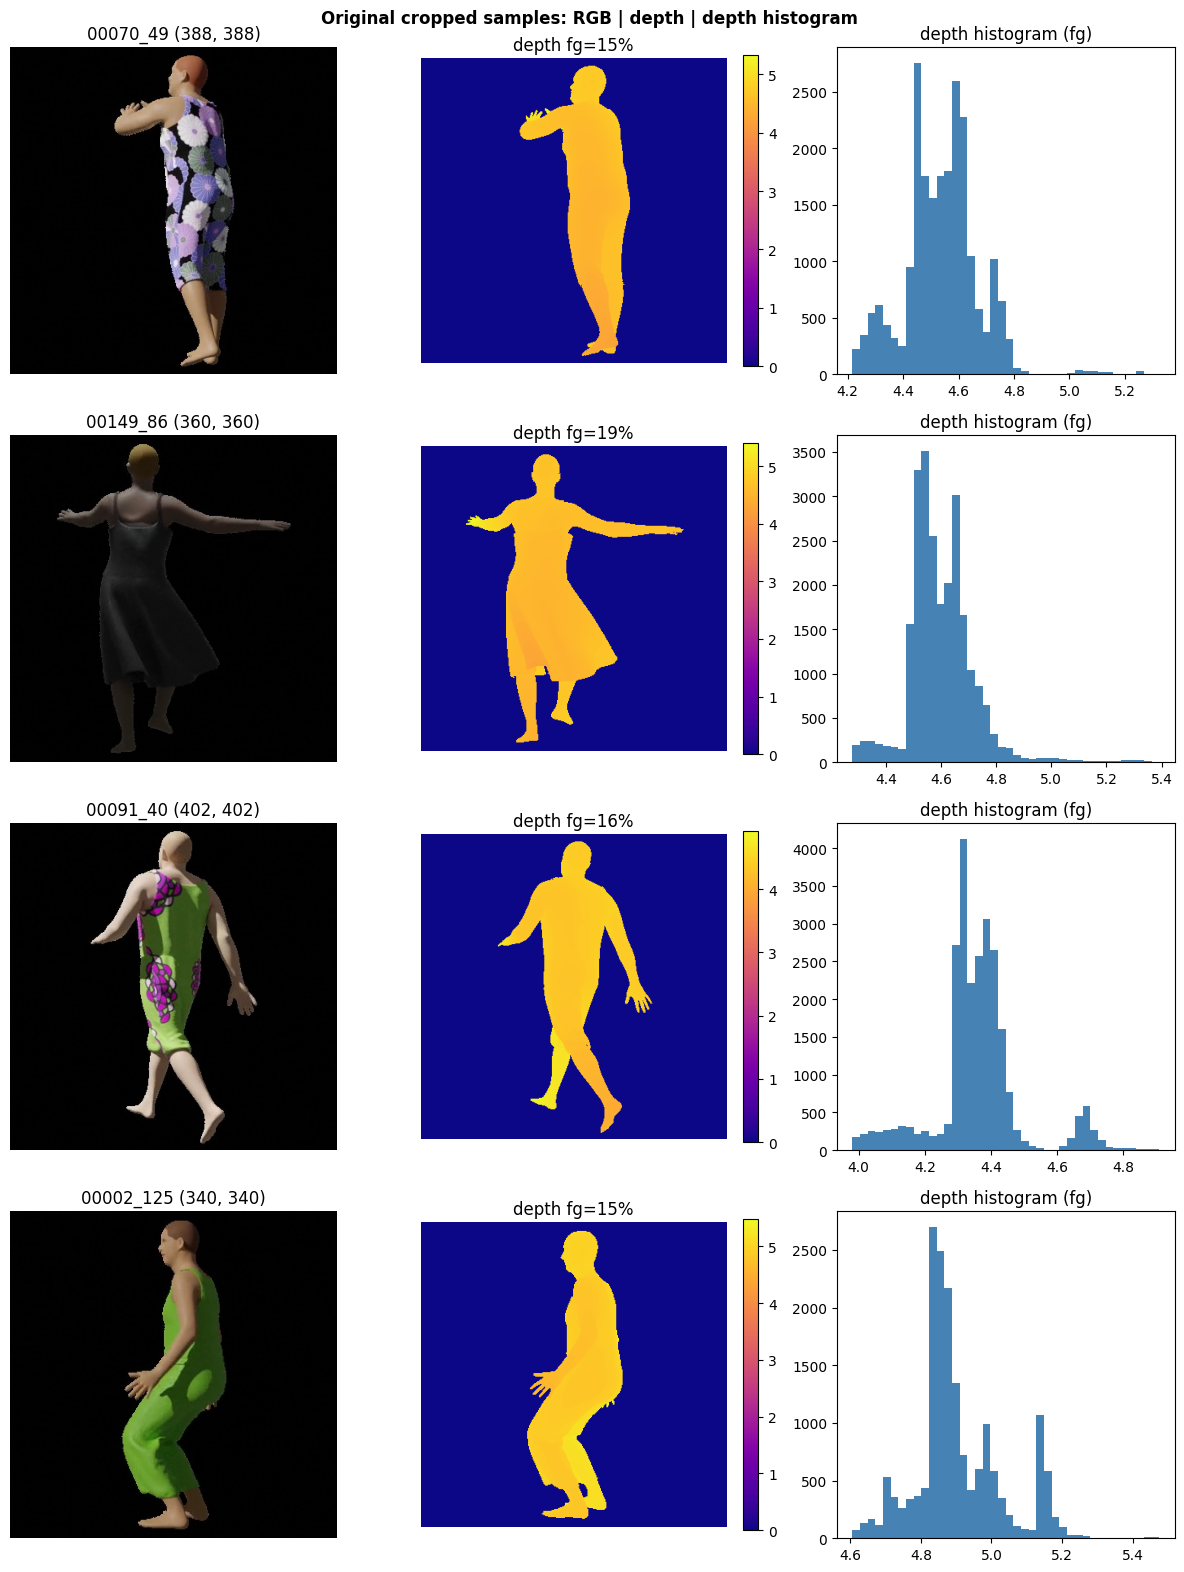

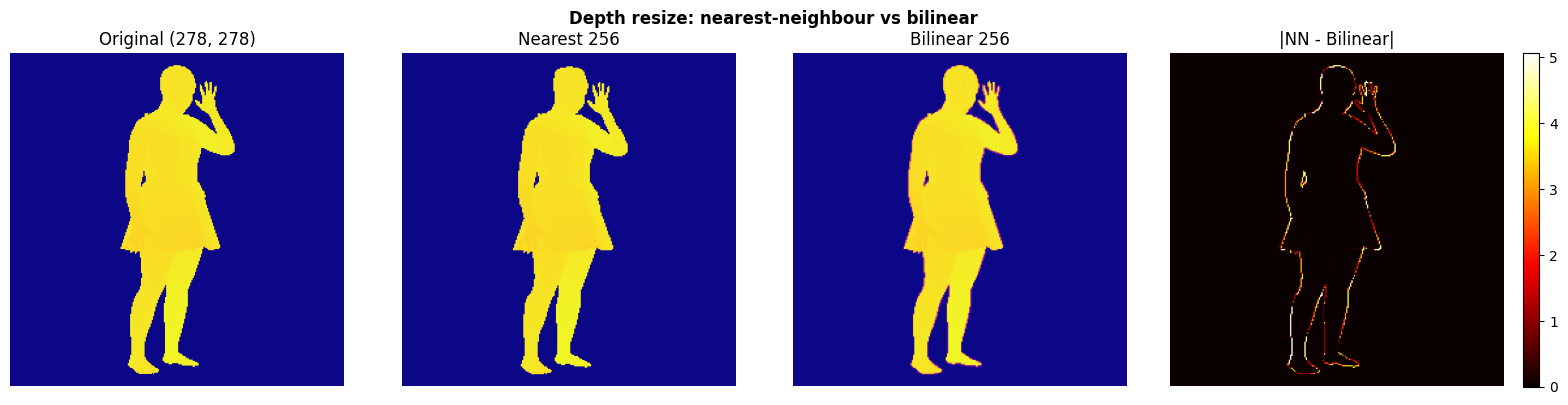

Foreground ratio original: 16.6%
Foreground ratio NN      : 16.6%
Foreground ratio Bilinear: 17.4%


In [4]:
viz_names = rng.sample(all_list, 4)
fig, axes = plt.subplots(len(viz_names), 3, figsize=(12, 4 * len(viz_names)))
fig.suptitle('Original cropped samples: RGB | depth | depth histogram', fontweight='bold')

for row, name in enumerate(viz_names):
    img = cv2.cvtColor(cv2.imread(str(SOURCE_ROOT / 'image' / f'{name}.jpg')), cv2.COLOR_BGR2RGB)
    dpt = np.load(SOURCE_ROOT / 'depth' / f'{name}.npy')
    mask = dpt > 0
    axes[row, 0].imshow(img); axes[row, 0].set_title(f'{name} {img.shape[:2]}'); axes[row, 0].axis('off')
    im = axes[row, 1].imshow(dpt, cmap='plasma'); axes[row, 1].set_title(f'depth fg={mask.mean()*100:.0f}%'); axes[row, 1].axis('off')
    plt.colorbar(im, ax=axes[row, 1], fraction=0.046)
    axes[row, 2].hist(dpt[mask].ravel(), bins=40, color='steelblue', edgecolor='none')
    axes[row, 2].set_title('depth histogram (fg)')

plt.tight_layout()
plt.savefig(FIG_ROOT / 'eda_samples.png', dpi=120)
plt.show()

name = train_list[0]
dpt = np.load(SOURCE_ROOT / 'depth' / f'{name}.npy')
dpt_nn = cv2.resize(dpt, (256, 256), interpolation=cv2.INTER_NEAREST)
dpt_bil = cv2.resize(dpt, (256, 256), interpolation=cv2.INTER_LINEAR)
diff = np.abs(dpt_nn.astype(np.float32) - dpt_bil.astype(np.float32))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Depth resize: nearest-neighbour vs bilinear', fontweight='bold')
axes[0].imshow(dpt, cmap='plasma'); axes[0].set_title(f'Original {dpt.shape}'); axes[0].axis('off')
axes[1].imshow(dpt_nn, cmap='plasma'); axes[1].set_title('Nearest 256'); axes[1].axis('off')
axes[2].imshow(dpt_bil, cmap='plasma'); axes[2].set_title('Bilinear 256'); axes[2].axis('off')
im = axes[3].imshow(diff, cmap='hot'); axes[3].set_title('|NN - Bilinear|'); axes[3].axis('off')
plt.colorbar(im, ax=axes[3], fraction=0.046)
plt.tight_layout()
plt.savefig(FIG_ROOT / 'eda_interp.png', dpi=120)
plt.show()

print(f'Foreground ratio original: {(dpt > 0).mean()*100:.1f}%')
print(f'Foreground ratio NN      : {(dpt_nn > 0).mean()*100:.1f}%')
print(f'Foreground ratio Bilinear: {(dpt_bil > 0).mean()*100:.1f}%')


## 3 - Repeatable Resized Dataset Variants


In [5]:
def variant_path(size, depth_interp):
    return VARIANT_ROOT / f'{size}_{depth_interp}'


def ensure_resized_variant(source_root, size, depth_interp='nearest'):
    assert depth_interp in {'nearest', 'bilinear'}
    dst_root = variant_path(size, depth_interp)
    img_src = source_root / 'image'
    dpt_src = source_root / 'depth'
    img_dst = dst_root / 'image'
    dpt_dst = dst_root / 'depth'
    marker = dst_root / '_complete.json'

    expected_count = len(list(img_src.glob('*.jpg')))
    if marker.exists() and img_dst.exists() and dpt_dst.exists():
        current_count = len(list(img_dst.glob('*.jpg')))
        if current_count == expected_count:
            print(f'{dst_root.name}: already complete ({current_count} samples)')
            return dst_root

    img_dst.mkdir(parents=True, exist_ok=True)
    dpt_dst.mkdir(parents=True, exist_ok=True)
    for split_file in ['train.txt', 'validation.txt', 'test.txt']:
        shutil.copy2(source_root / split_file, dst_root / split_file)

    interp_flag = cv2.INTER_NEAREST if depth_interp == 'nearest' else cv2.INTER_LINEAR
    img_files = sorted(img_src.glob('*.jpg'))
    print(f'Creating {dst_root.name}: {len(img_files)} samples at {size}x{size}, depth={depth_interp}')

    t0 = time.time()
    for i, img_file in enumerate(img_files, 1):
        stem = img_file.stem
        img = cv2.imread(str(img_file))
        if img is None:
            raise RuntimeError(f'Could not read image: {img_file}')
        img = cv2.resize(img, (size, size), interpolation=cv2.INTER_LINEAR)
        cv2.imwrite(str(img_dst / f'{stem}.jpg'), img, [cv2.IMWRITE_JPEG_QUALITY, 95])

        dpt = np.load(dpt_src / f'{stem}.npy').astype(np.float32)
        dpt = cv2.resize(dpt, (size, size), interpolation=interp_flag)
        np.save(dpt_dst / f'{stem}.npy', dpt.astype(np.float16))

        if i % 2000 == 0 or i == len(img_files):
            print(f'  {i:5d}/{len(img_files)} ({time.time() - t0:.1f}s)')

    marker.write_text(json.dumps({
        'source': str(source_root),
        'size': size,
        'depth_interp': depth_interp,
        'samples': len(img_files),
        'created_at': time.strftime('%Y-%m-%d %H:%M:%S'),
    }, indent=2), encoding='utf-8')
    print(f'Done: {dst_root}')
    return dst_root


root_256_nearest = ensure_resized_variant(SOURCE_ROOT, 256, 'nearest')
root_384_nearest = ensure_resized_variant(SOURCE_ROOT, 384, 'nearest')
root_256_bilinear = ensure_resized_variant(SOURCE_ROOT, 256, 'bilinear')

total, used, free = shutil.disk_usage(PROJECT_ROOT)
print(f'Disk: {used/1e9:.1f} GB used / {total/1e9:.1f} GB total ({free/1e9:.1f} GB free)')


256_nearest: already complete (36435 samples)
384_nearest: already complete (36435 samples)
256_bilinear: already complete (36435 samples)
Disk: 773.7 GB used / 999.2 GB total (225.5 GB free)


## 4 - Dataset & Augmentation


In [6]:
class Cloth3DDataset(Dataset):
    def __init__(self, data_list, root, img_size=256, augment=False, cfg=None):
        self.data_list = data_list
        self.root = Path(root)
        self.img_size = img_size
        self.augment = augment
        self.cfg = cfg or {}

    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        name = self.data_list[idx]
        s = self.img_size

        dpt = np.load(self.root / 'depth' / f'{name}.npy').astype(np.float32)
        img = cv2.cvtColor(cv2.imread(str(self.root / 'image' / f'{name}.jpg')), cv2.COLOR_BGR2RGB).astype(np.float32)
        mask = dpt > 0

        if self.augment:
            img, dpt = self._augment(img, dpt, s)
            mask = dpt > 0

        if mask.any():
            dpt[mask] = (dpt[mask] - dpt[mask].min() + 0.001) / 2.0

        if mask.any():
            for c in range(3):
                ch = img[:, :, c]
                mu, sigma = ch[mask].mean(), ch[mask].std()
                img[:, :, c] = (ch - mu) / (sigma + 1e-5)

        img = torch.from_numpy(img).permute(2, 0, 1).float()
        dpt = torch.from_numpy(dpt).unsqueeze(0).float()
        return img, dpt

    def _augment(self, img, dpt, s):
        cfg = self.cfg

        if cfg.get('aug_hflip', True) and random.random() > 0.5:
            img = img[:, ::-1, :].copy()
            dpt = dpt[:, ::-1].copy()

        M = np.eye(3, dtype=np.float32)
        cx, cy = s / 2, s / 2

        if cfg.get('aug_rotate', True):
            rad = np.deg2rad(random.uniform(-15, 15))
            R = np.array([[np.cos(rad), -np.sin(rad), 0],
                          [np.sin(rad),  np.cos(rad), 0],
                          [0, 0, 1]], dtype=np.float32)
            T1 = np.array([[1, 0, -cx], [0, 1, -cy], [0, 0, 1]], dtype=np.float32)
            T2 = np.array([[1, 0,  cx], [0, 1,  cy], [0, 0, 1]], dtype=np.float32)
            M = T2 @ R @ T1 @ M

        if cfg.get('aug_shear', True):
            shx = np.deg2rad(random.uniform(-10, 10))
            shy = np.deg2rad(random.uniform(-10, 10))
            Sh = np.array([[1, np.tan(shx), 0],
                           [np.tan(shy), 1, 0],
                           [0, 0, 1]], dtype=np.float32)
            M = Sh @ M

        if cfg.get('aug_shift', True):
            M[0, 2] += random.uniform(-0.1, 0.1) * s
            M[1, 2] += random.uniform(-0.1, 0.1) * s

        aff = M[:2]
        img = cv2.warpAffine(img, aff, (s, s), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=0)
        dpt = cv2.warpAffine(dpt, aff, (s, s), flags=cv2.INTER_NEAREST, borderMode=cv2.BORDER_CONSTANT, borderValue=0)

        if cfg.get('aug_scale', True):
            scale = random.uniform(0.8, 1.0)
            crop = int(s * scale)
            x0 = random.randint(0, s - crop)
            y0 = random.randint(0, s - crop)
            img = cv2.resize(img[y0:y0+crop, x0:x0+crop], (s, s), interpolation=cv2.INTER_LINEAR)
            dpt = cv2.resize(dpt[y0:y0+crop, x0:x0+crop], (s, s), interpolation=cv2.INTER_NEAREST)

        return img, dpt


## 5 - Lightweight UNet Baseline


In [7]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.GELU(),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False), nn.BatchNorm2d(out_ch), nn.GELU(),
        )
    def forward(self, x):
        return self.block(x)


class UNet(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, features=(64, 128, 256, 512, 1024)):
        super().__init__()
        self.encoders = nn.ModuleList()
        self.pools = nn.ModuleList()
        ch = in_ch
        for f in features[:-1]:
            self.encoders.append(ConvBlock(ch, f))
            self.pools.append(nn.MaxPool2d(2))
            ch = f

        self.bottleneck = ConvBlock(ch, features[-1])
        self.upconvs = nn.ModuleList()
        self.decoders = nn.ModuleList()
        rev = list(reversed(features[:-1]))
        ch = features[-1]
        for f in rev:
            self.upconvs.append(nn.ConvTranspose2d(ch, f, 2, stride=2))
            self.decoders.append(ConvBlock(f * 2, f))
            ch = f

        self.head = nn.Sequential(nn.Conv2d(ch, out_ch, 1), nn.Sigmoid())

    def forward(self, x):
        skips = []
        for enc, pool in zip(self.encoders, self.pools):
            x = enc(x)
            skips.append(x)
            x = pool(x)
        x = self.bottleneck(x)
        for up, dec, skip in zip(self.upconvs, self.decoders, reversed(skips)):
            x = up(x)
            if x.shape != skip.shape:
                x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=False)
            x = dec(torch.cat([skip, x], dim=1))
        return self.head(x)


## 6 - Metrics


In [8]:
def rmse(pred, gt):
    mask = gt > 0
    if not mask.any():
        return torch.tensor(0.0, device=pred.device)
    return torch.sqrt(F.mse_loss(pred[mask], gt[mask]))


def depth_to_normals(depth, eps=1e-6):
    dz_dx = depth[:, :, :, 2:] - depth[:, :, :, :-2]
    dz_dy = depth[:, :, 2:, :] - depth[:, :, :-2, :]
    dz_dx = F.pad(dz_dx, [1, 1, 0, 0])
    dz_dy = F.pad(dz_dy, [0, 0, 1, 1])
    n = torch.cat([-dz_dx, -dz_dy, torch.ones_like(dz_dx)], dim=1)
    return n / (torch.norm(n, dim=1, keepdim=True) + eps)


def mean_angular_error(pred_depth, gt_depth):
    mask = (gt_depth > 0).squeeze(1)
    n_pred = depth_to_normals(pred_depth)
    n_gt = depth_to_normals(gt_depth)
    cos_sim = (n_pred * n_gt).sum(dim=1).clamp(-1.0, 1.0)
    angle = torch.acos(cos_sim) * (180.0 / torch.pi)
    if not mask.any():
        return torch.tensor(0.0, device=pred_depth.device)
    return angle[mask].mean()


## 7 - Training & Evaluation Utilities


In [9]:
def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def make_loader(data_list, cfg, augment, shuffle, batch_size=None):
    ds = Cloth3DDataset(data_list, cfg['root'], cfg['img_size'], augment=augment, cfg=cfg)
    return DataLoader(
        ds,
        batch_size=batch_size or cfg['batch_size'],
        shuffle=shuffle,
        num_workers=NUM_WORKERS,
        pin_memory=(DEVICE == 'cuda'),
    )


def train_epoch(model, loader, optimizer):
    model.train()
    total = 0.0
    for X, Y in loader:
        X, Y = X.to(DEVICE, non_blocking=True), Y.to(DEVICE, non_blocking=True)
        pred = model(X)
        loss = F.mse_loss(pred, Y)
        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()
        total += loss.item()
    return total / max(1, len(loader))


@torch.no_grad()
def val_epoch(model, loader):
    model.eval()
    tot_rmse, tot_mae, n = 0.0, 0.0, 0
    for X, Y in loader:
        X, Y = X.to(DEVICE, non_blocking=True), Y.to(DEVICE, non_blocking=True)
        pred = model(X)
        tot_rmse += rmse(pred, Y).item()
        tot_mae += mean_angular_error(pred, Y).item()
        n += 1
    return tot_rmse / max(1, n), tot_mae / max(1, n)


def save_latest(path, model, optimizer, scheduler, epoch, best_rmse, patience_ctr, history):
    torch.save({
        'epoch': epoch,
        'model': model.state_dict(),
        'optimizer': optimizer.state_dict(),
        'scheduler': scheduler.state_dict(),
        'best_rmse': best_rmse,
        'patience_ctr': patience_ctr,
        'history': history,
    }, path)


def train(cfg, train_list, val_list):
    set_seed(cfg.get('seed', 42))
    model = UNet().to(DEVICE)
    tr_dl = make_loader(train_list, cfg, augment=True, shuffle=True)
    vl_dl = make_loader(val_list, cfg, augment=False, shuffle=False)

    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg['lr'], weight_decay=cfg['weight_decay'])
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=cfg['epochs'])

    best_rmse, patience_ctr = float('inf'), 0
    history = {'train_loss': [], 'val_rmse': [], 'val_mae_n': [], 'epoch_seconds': []}
    start_epoch = 0

    latest_path = Path(cfg['latest_checkpoint'])
    if latest_path.exists() and cfg.get('resume', True):
        print(f'Resuming from {latest_path}')
        ckpt = torch.load(latest_path, map_location=DEVICE, weights_only=False)
        model.load_state_dict(ckpt['model'])
        optimizer.load_state_dict(ckpt['optimizer'])
        scheduler.load_state_dict(ckpt['scheduler'])
        start_epoch = ckpt['epoch'] + 1
        best_rmse = ckpt['best_rmse']
        patience_ctr = ckpt['patience_ctr']
        history = ckpt['history']

    for epoch in range(start_epoch, cfg['epochs']):
        t0 = time.time()
        tr_loss = train_epoch(model, tr_dl, optimizer)
        v_rmse, v_mae = val_epoch(model, vl_dl)
        scheduler.step()
        elapsed = time.time() - t0

        history['train_loss'].append(tr_loss)
        history['val_rmse'].append(v_rmse)
        history['val_mae_n'].append(v_mae)
        history['epoch_seconds'].append(elapsed)

        print(f'Epoch {epoch+1:02d}/{cfg["epochs"]} | loss={tr_loss:.4f} | val_RMSE={v_rmse:.4f} | val_NormalMAE={v_mae:.2f} deg | {elapsed:.1f}s')

        if v_rmse < best_rmse:
            best_rmse = v_rmse
            torch.save(model.state_dict(), cfg['checkpoint'])
            patience_ctr = 0
        else:
            patience_ctr += 1
            if patience_ctr >= cfg['patience']:
                print(f'Early stopping at epoch {epoch+1}')
                break

        save_latest(latest_path, model, optimizer, scheduler, epoch, best_rmse, patience_ctr, history)

    with open(cfg['history_path'], 'wb') as fh:
        pickle.dump(history, fh)

    print(f'Best val RMSE: {best_rmse:.4f}')
    return model, history, best_rmse


@torch.no_grad()
def evaluate(model, test_list, cfg, label=''):
    model.eval()
    model.load_state_dict(torch.load(cfg['checkpoint'], map_location=DEVICE, weights_only=True))
    dl = make_loader(test_list, cfg, augment=False, shuffle=False, batch_size=1)

    tot_rmse, tot_mae = 0.0, 0.0
    fps_times = []
    if DEVICE == 'cuda':
        torch.cuda.reset_peak_memory_stats()

    for X, Y in dl:
        X, Y = X.to(DEVICE, non_blocking=True), Y.to(DEVICE, non_blocking=True)
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        t0 = time.time()
        pred = model(X)
        if DEVICE == 'cuda':
            torch.cuda.synchronize()
        fps_times.append(time.time() - t0)
        tot_rmse += rmse(pred, Y).item()
        tot_mae += mean_angular_error(pred, Y).item()

    n = len(dl)
    params = sum(p.numel() for p in model.parameters())
    gpu_mb = torch.cuda.max_memory_allocated() / 1024**2 if DEVICE == 'cuda' else 0.0
    fps = 1.0 / (sum(fps_times) / len(fps_times))

    result = {
        'label': label,
        'status': 'ok',
        'val_rmse': min(cfg.get('history_val_rmse', [float('inf')])),
        'test_rmse': tot_rmse / n,
        'normal_mae': tot_mae / n,
        'fps': fps,
        'params': params,
        'gpu_mb': gpu_mb,
        'img_size': cfg['img_size'],
        'depth_interp': cfg['depth_interp'],
        'lr': cfg['lr'],
        'batch_size': cfg['batch_size'],
        'aug_hflip': cfg['aug_hflip'],
        'aug_shift': cfg['aug_shift'],
        'aug_scale': cfg['aug_scale'],
        'aug_rotate': cfg['aug_rotate'],
        'aug_shear': cfg['aug_shear'],
        'checkpoint': str(cfg['checkpoint']),
        'history_path': str(cfg['history_path']),
    }

    print('=' * 72)
    print(label)
    print(f'  Test RMSE         : {result["test_rmse"]:.4f}')
    print(f'  Normal MAE        : {result["normal_mae"]:.2f} deg')
    print(f'  FPS               : {result["fps"]:.1f}')
    print(f'  Parameters        : {result["params"]:,}')
    print(f'  Peak GPU mem (MB) : {result["gpu_mb"]:.1f}')
    print('=' * 72)
    return result


def cleanup_cuda():
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()


## 8 - Automatic Experiment Plan


In [10]:
BASE_CONFIG = {
    'root': root_256_nearest,
    'img_size': 256,
    'depth_interp': 'nearest',
    'aug_hflip': True,
    'aug_shift': True,
    'aug_scale': True,
    'aug_rotate': True,
    'aug_shear': True,
    'batch_size': 8,
    'lr': 1e-3,
    'weight_decay': 1e-4,
    'epochs': 8,
    'patience': 8,
    'seed': 42,
    'resume': True,
}


def slugify(label):
    return ''.join(ch.lower() if ch.isalnum() else '_' for ch in label).strip('_')


def aug_name(overrides):
    cfg = {**BASE_CONFIG, **overrides}
    if not any(cfg[k] for k in ['aug_hflip', 'aug_shift', 'aug_scale', 'aug_rotate', 'aug_shear']):
        return 'no_aug'
    if cfg['aug_hflip'] and cfg['aug_scale'] and not cfg['aug_shift'] and not cfg['aug_rotate'] and not cfg['aug_shear']:
        return 'flip_scale'
    if cfg['aug_hflip'] and cfg['aug_shift'] and cfg['aug_scale'] and cfg['aug_rotate'] and not cfg['aug_shear']:
        return 'flip_shift_scale_rot'
    if all(cfg[k] for k in ['aug_hflip', 'aug_shift', 'aug_scale', 'aug_rotate', 'aug_shear']):
        return 'full_aug'
    return 'custom_aug'


def lr_name(lr):
    return f'lr{lr:.0e}'.replace('+0', '').replace('-0', '-')


def build_label(img_size, depth_interp, overrides, prefix=None):
    cfg = {**BASE_CONFIG, **overrides, 'img_size': img_size, 'depth_interp': depth_interp}
    parts = [str(img_size), depth_interp, aug_name(cfg), lr_name(cfg['lr']), f'bs{cfg["batch_size"]}']
    if prefix:
        parts.insert(0, prefix)
    return '_'.join(parts)


def build_cfg(label, overrides):
    tag = slugify(label)
    cfg = {**BASE_CONFIG, **overrides}
    cfg['root'] = Path(cfg['root'])
    cfg['checkpoint'] = CKPT_ROOT / f'unet_{tag}.pth'
    cfg['latest_checkpoint'] = CKPT_ROOT / f'latest_{tag}.pth'
    cfg['history_path'] = HIST_ROOT / f'hist_{tag}.pkl'
    cfg['result_path'] = METRIC_ROOT / f'result_{tag}.json'
    return cfg


def result_from_cfg(label, cfg, status='ok', **metrics):
    return {
        'label': label,
        'status': status,
        'val_rmse': metrics.get('val_rmse', float('inf')),
        'test_rmse': metrics.get('test_rmse', float('inf')),
        'normal_mae': metrics.get('normal_mae', float('inf')),
        'fps': metrics.get('fps', 0.0),
        'params': metrics.get('params', 0),
        'gpu_mb': metrics.get('gpu_mb', 0.0),
        'img_size': cfg['img_size'],
        'depth_interp': cfg['depth_interp'],
        'root': str(cfg['root']),
        'lr': cfg['lr'],
        'batch_size': cfg['batch_size'],
        'aug_hflip': cfg['aug_hflip'],
        'aug_shift': cfg['aug_shift'],
        'aug_scale': cfg['aug_scale'],
        'aug_rotate': cfg['aug_rotate'],
        'aug_shear': cfg['aug_shear'],
        'checkpoint': str(cfg['checkpoint']),
        'latest_checkpoint': str(cfg['latest_checkpoint']),
        'history_path': str(cfg['history_path']),
        'result_path': str(cfg['result_path']),
    }


def save_result(result):
    Path(result['result_path']).write_text(json.dumps(result, indent=2), encoding='utf-8')
    return result


def load_result_json(cfg):
    if cfg['result_path'].exists():
        result = json.loads(cfg['result_path'].read_text(encoding='utf-8'))
        # Older cached results may not have every metadata field used by later tables.
        result.setdefault('root', str(cfg['root']))
        result.setdefault('checkpoint', str(cfg['checkpoint']))
        result.setdefault('latest_checkpoint', str(cfg['latest_checkpoint']))
        result.setdefault('history_path', str(cfg['history_path']))
        result.setdefault('result_path', str(cfg['result_path']))
        for key in ['img_size', 'depth_interp', 'lr', 'batch_size', 'aug_hflip', 'aug_shift', 'aug_scale', 'aug_rotate', 'aug_shear']:
            result.setdefault(key, cfg[key])
        print(f'Found saved metrics: {cfg["result_path"].name}; skipping training.')
        return save_result(result)
    return None




def load_result_csv(label, cfg):
    for csv_path in [RUNS_ROOT / 'd1_results_so_far.csv', RUNS_ROOT / 'd1_results.csv']:
        if not csv_path.exists():
            continue
        try:
            df_cache = pd.read_csv(csv_path)
        except Exception:
            continue
        if 'label' not in df_cache.columns:
            continue
        rows = df_cache[df_cache['label'] == label]
        if len(rows) == 0:
            continue
        result = rows.iloc[-1].to_dict()
        result.update({
            'label': label,
            'root': str(cfg['root']),
            'checkpoint': str(cfg['checkpoint']),
            'latest_checkpoint': str(cfg['latest_checkpoint']),
            'history_path': str(cfg['history_path']),
            'result_path': str(cfg['result_path']),
        })
        for k in ['img_size', 'batch_size', 'params']:
            if k in result:
                result[k] = int(result[k])
        for k in ['val_rmse', 'test_rmse', 'normal_mae', 'fps', 'gpu_mb', 'lr']:
            if k in result:
                result[k] = float(result[k])
        for k in ['aug_hflip', 'aug_shift', 'aug_scale', 'aug_rotate', 'aug_shear']:
            if k in result:
                result[k] = bool(result[k])
        print(f'Found saved CSV row in {csv_path.name}; skipping training and writing metrics JSON.')
        return save_result(result)
    return None

def recover_result_from_checkpoint(label, cfg):
    if cfg['checkpoint'].exists() and cfg['history_path'].exists():
        print(f'Found checkpoint/history for {label}; evaluating once and saving metrics.')
        history = pickle.load(open(cfg['history_path'], 'rb'))
        cfg['history_val_rmse'] = history.get('val_rmse', [])
        model = UNet().to(DEVICE)
        result = evaluate(model, test_list, cfg, label=label)
        result['val_rmse'] = min(history.get('val_rmse', [float('inf')]))
        result['result_path'] = str(cfg['result_path'])
        return save_result(result)
    return None


def append_and_save(result):
    existing = {r['label']: r for r in results}
    existing[result['label']] = result
    results.clear()
    results.extend(existing.values())
    pd.DataFrame(results).to_csv(RUNS_ROOT / 'd1_results_so_far.csv', index=False)


def run_exp(label, overrides):
    print('\n' + '#' * 72)
    print(f'RUN: {label}')
    print('#' * 72)
    cfg = build_cfg(label, overrides)

    cached = load_result_json(cfg) or load_result_csv(label, cfg) or recover_result_from_checkpoint(label, cfg)
    if cached is not None:
        append_and_save(cached)
        return cached

    try:
        model, history, best_val_rmse = train(cfg, train_list, val_list)
        cfg['history_val_rmse'] = history['val_rmse']
        result = evaluate(model, test_list, cfg, label=label)
        result['val_rmse'] = best_val_rmse
        result['result_path'] = str(cfg['result_path'])
        result = save_result(result)
    except RuntimeError as exc:
        message = str(exc)
        if 'out of memory' in message.lower():
            print(f'Out of memory during {label}; recording failed run and continuing.')
            result = result_from_cfg(label, cfg, status='failed_oom')
            result = save_result(result)
        else:
            raise
    finally:
        cleanup_cuda()

    append_and_save(result)
    return result


def summarize_group(title, group_results, decision_note=None):
    cols = ['label', 'status', 'val_rmse', 'test_rmse', 'normal_mae', 'fps', 'gpu_mb']
    df_group = pd.DataFrame(group_results)[cols].sort_values(['status', 'val_rmse']).reset_index(drop=True)
    print('\n' + '=' * 72)
    print(title)
    print('=' * 72)
    print(df_group.to_string(index=False))
    ok = [r for r in group_results if r['status'] == 'ok']
    best = min(ok, key=lambda r: r['val_rmse'])
    print(f'\nDecision: {best["label"]} selected by lowest validation RMSE ({best["val_rmse"]:.4f}).')
    if decision_note:
        print(decision_note(best))
    return best, df_group


def aug_overrides_from_result(result):
    return {
        'aug_hflip': result['aug_hflip'],
        'aug_shift': result['aug_shift'],
        'aug_scale': result['aug_scale'],
        'aug_rotate': result['aug_rotate'],
        'aug_shear': result['aug_shear'],
    }


def root_for(size, depth_interp):
    if size == 256 and depth_interp == 'nearest':
        return root_256_nearest
    if size == 256 and depth_interp == 'bilinear':
        return root_256_bilinear
    if size == 384 and depth_interp == 'nearest':
        return root_384_nearest
    if size == 384 and depth_interp == 'bilinear':
        return ensure_resized_variant(SOURCE_ROOT, 384, 'bilinear')
    raise ValueError((size, depth_interp))


results = []

## 9 - Run Experiments Sequentially


In [11]:
# Stage 1: interpolation is a preprocessing decision, so it is fixed before every later stage.
INTERP_BASE_AUG = {
    'aug_hflip': True,
    'aug_shift': True,
    'aug_scale': True,
    'aug_rotate': True,
    'aug_shear': True,
}

interpolation_results = []
for interp in ['nearest', 'bilinear']:
    label = build_label(256, interp, {**INTERP_BASE_AUG, 'lr': 1e-3, 'batch_size': 8})
    interpolation_results.append(run_exp(label, {
        **INTERP_BASE_AUG,
        'root': root_for(256, interp),
        'img_size': 256,
        'depth_interp': interp,
        'lr': 1e-3,
        'batch_size': 8,
    }))

best_interp_result, interpolation_table = summarize_group(
    'Stage 1 decision - interpolation method',
    interpolation_results,
    lambda r: f'All later 256px experiments will use depth_interp={r["depth_interp"]}.'
)
BEST_INTERP = best_interp_result['depth_interp']
BEST_INTERP_ROOT_256 = root_for(256, BEST_INTERP)

# Stage 2: augmentation ablation at 256px using the winning interpolation.
augmentation_specs = [
    ('no_aug', {
        'aug_hflip': False,
        'aug_shift': False,
        'aug_scale': False,
        'aug_rotate': False,
        'aug_shear': False,
    }),
    ('flip_scale', {
        'aug_hflip': True,
        'aug_shift': False,
        'aug_scale': True,
        'aug_rotate': False,
        'aug_shear': False,
    }),
    ('flip_shift_scale_rot', {
        'aug_hflip': True,
        'aug_shift': True,
        'aug_scale': True,
        'aug_rotate': True,
        'aug_shear': False,
    }),
    ('full_aug', {
        'aug_hflip': True,
        'aug_shift': True,
        'aug_scale': True,
        'aug_rotate': True,
        'aug_shear': True,
    }),
]

augmentation_results = []
for _, aug_cfg in augmentation_specs:
    label = build_label(256, BEST_INTERP, {**aug_cfg, 'lr': 1e-3, 'batch_size': 8})
    augmentation_results.append(run_exp(label, {
        **aug_cfg,
        'root': BEST_INTERP_ROOT_256,
        'img_size': 256,
        'depth_interp': BEST_INTERP,
        'lr': 1e-3,
        'batch_size': 8,
    }))

best_aug_result, augmentation_table = summarize_group(
    'Stage 2 decision - augmentation policy',
    augmentation_results,
    lambda r: f'All later experiments will use {aug_name(r)}.'
)
BEST_AUG = aug_overrides_from_result(best_aug_result)

# Stage 3: LR / batch size using the fixed preprocessing and augmentation pipeline.
lr_batch_specs = [
    {'lr': 1e-3, 'batch_size': 8},
    {'lr': 1e-4, 'batch_size': 8},
    {'lr': 1e-3, 'batch_size': 16},
    {'lr': 1e-3, 'batch_size': 4},
]

lr_batch_results = []
for opt_cfg in lr_batch_specs:
    label = build_label(256, BEST_INTERP, {**BEST_AUG, **opt_cfg})
    lr_batch_results.append(run_exp(label, {
        **BEST_AUG,
        **opt_cfg,
        'root': BEST_INTERP_ROOT_256,
        'img_size': 256,
        'depth_interp': BEST_INTERP,
    }))

best_opt_result, lr_batch_table = summarize_group(
    'Stage 3 decision - learning rate and batch size',
    lr_batch_results,
    lambda r: f'Final resolution comparison will use lr={r["lr"]} and batch_size={r["batch_size"]}.'
)
BEST_OPT = {'lr': best_opt_result['lr'], 'batch_size': best_opt_result['batch_size']}

# Stage 4: resolution last, using the best fixed pipeline found above.
resolution_results = []
for size in [256, 384]:
    batch_size = BEST_OPT['batch_size']
    if size == 384 and batch_size > 8:
        batch_size = 8
        print('Reducing 384px batch size to 8 to reduce OOM risk while preserving the selected LR.')
    label = build_label(size, BEST_INTERP, {**BEST_AUG, 'lr': BEST_OPT['lr'], 'batch_size': batch_size})
    resolution_results.append(run_exp(label, {
        **BEST_AUG,
        'root': root_for(size, BEST_INTERP),
        'img_size': size,
        'depth_interp': BEST_INTERP,
        'lr': BEST_OPT['lr'],
        'batch_size': batch_size,
    }))

best_resolution_result, resolution_table = summarize_group(
    'Stage 4 decision - resolution',
    resolution_results,
    lambda r: f'Best final configuration is {r["label"]}.'
)

STAGE_DECISIONS = {
    'best_interpolation': best_interp_result,
    'best_augmentation': best_aug_result,
    'best_optimizer': best_opt_result,
    'best_resolution': best_resolution_result,
}
(Path(RUNS_ROOT) / 'd1_stage_decisions.json').write_text(json.dumps(STAGE_DECISIONS, indent=2), encoding='utf-8')


########################################################################
RUN: 256_nearest_full_aug_lr1e-3_bs8
########################################################################
Epoch 01/8 | loss=0.0037 | val_RMSE=0.1029 | val_NormalMAE=1.85 deg | 691.1s
Epoch 02/8 | loss=0.0017 | val_RMSE=0.1011 | val_NormalMAE=1.68 deg | 677.2s
Epoch 03/8 | loss=0.0015 | val_RMSE=0.0978 | val_NormalMAE=1.69 deg | 677.8s
Epoch 04/8 | loss=0.0013 | val_RMSE=0.0954 | val_NormalMAE=1.72 deg | 676.9s
Epoch 05/8 | loss=0.0011 | val_RMSE=0.0956 | val_NormalMAE=1.71 deg | 676.9s
Epoch 06/8 | loss=0.0010 | val_RMSE=0.0957 | val_NormalMAE=1.69 deg | 677.6s
Epoch 07/8 | loss=0.0009 | val_RMSE=0.0946 | val_NormalMAE=1.64 deg | 678.8s
Epoch 08/8 | loss=0.0008 | val_RMSE=0.0929 | val_NormalMAE=1.65 deg | 677.0s
Best val RMSE: 0.0929
256_nearest_full_aug_lr1e-3_bs8
  Test RMSE         : 0.0678
  Normal MAE        : 1.42 deg
  FPS               : 163.7
  Parameters        : 31,037,633
  Peak GPU mem (MB) : 902

3841

## 10 - Results Table


Saved: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d1_unet\d1_results.csv
                                      label status  val_rmse  test_rmse  normal_mae        fps   params      gpu_mb  img_size depth_interp     lr  batch_size  aug_hflip  aug_shift  aug_scale  aug_rotate  aug_shear                                                                                                     root                                                                                                                             checkpoint                                                                                                                           result_path  params_m
              256_nearest_no_aug_lr1e-3_bs8     ok  0.088906   0.066027    1.128109 179.663453 31037633  352.501465       256      nearest 0.0010           8      False      False      False       False      False  C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\preprocessed_data\resized_variants\256

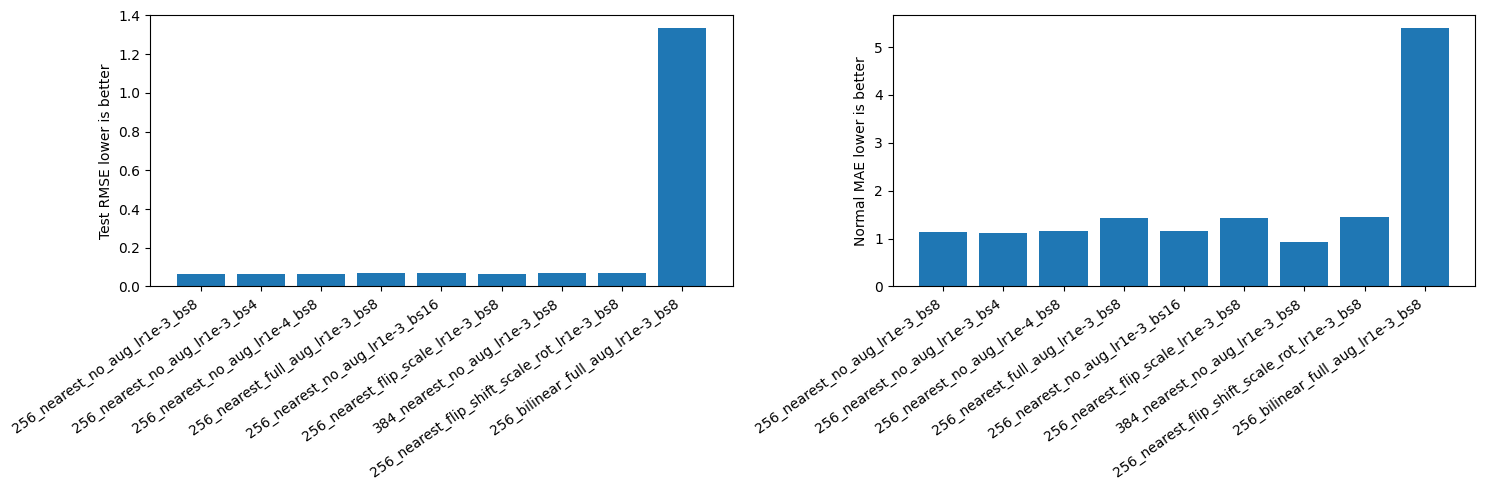

In [13]:
df = pd.DataFrame(results)
cols = [
    'label', 'status', 'val_rmse', 'test_rmse', 'normal_mae', 'fps', 'params', 'gpu_mb',
    'img_size', 'depth_interp', 'lr', 'batch_size',
    'aug_hflip', 'aug_shift', 'aug_scale', 'aug_rotate', 'aug_shear',
    'root', 'checkpoint', 'result_path',
]

# Backward compatibility for cached result records created before all metadata fields existed.
for col in cols:
    if col not in df.columns:
        df[col] = None
if 'root' in df.columns:
    missing_root = df['root'].isna() | (df['root'].astype(str) == '')
    df.loc[missing_root, 'root'] = df.loc[missing_root].apply(
        lambda r: str(VARIANT_ROOT / f'{int(r.img_size)}_{r.depth_interp}'), axis=1
    )

df = df[cols].sort_values(['status', 'val_rmse']).reset_index(drop=True)
df['params_m'] = df['params'] / 1e6
summary_path = RUNS_ROOT / 'd1_results.csv'
df.to_csv(summary_path, index=False)
print(f'Saved: {summary_path}')
print(df.to_string(index=False))

plot_df = df[df['status'] == 'ok'].copy()
if len(plot_df):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    x = np.arange(len(plot_df))
    axes[0].bar(x, plot_df['test_rmse']); axes[0].set_ylabel('Test RMSE lower is better')
    axes[1].bar(x, plot_df['normal_mae']); axes[1].set_ylabel('Normal MAE lower is better')
    for ax in axes:
        ax.set_xticks(x)
        ax.set_xticklabels(plot_df['label'], rotation=35, ha='right')
    plt.tight_layout()
    plt.savefig(FIG_ROOT / 'd1_results.png', dpi=150)
    plt.show()

## 11 - Training Curves & Qualitative Predictions


Best final run after staged decisions: 256_nearest_no_aug_lr1e-3_bs8


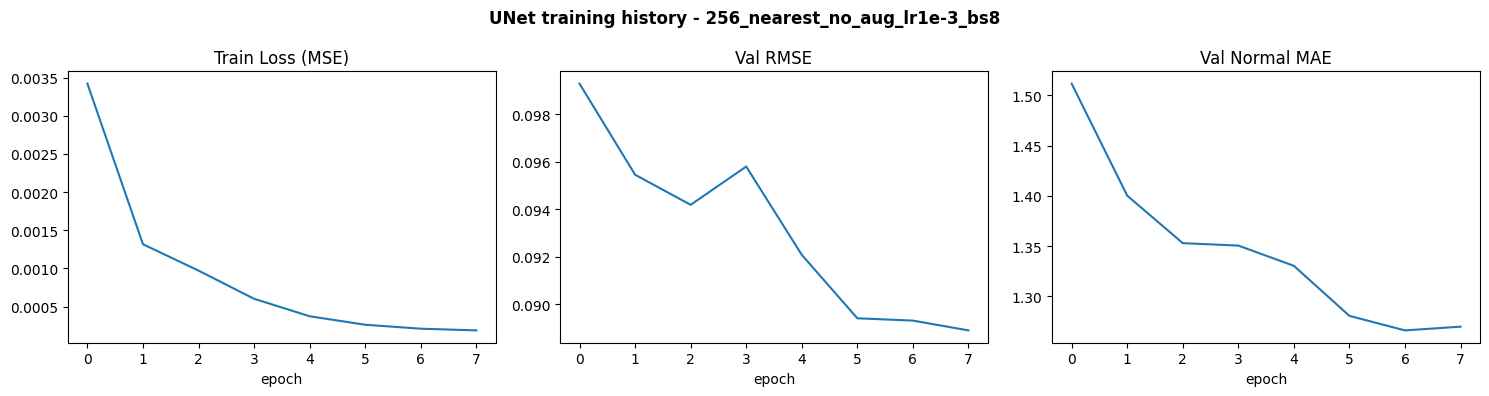

In [14]:
best_result = STAGE_DECISIONS['best_resolution']
print('Best final run after staged decisions:', best_result['label'])

hist = pickle.load(open(best_result['history_path'], 'rb'))
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(f'UNet training history - {best_result["label"]}', fontweight='bold')
axes[0].plot(hist['train_loss']); axes[0].set(title='Train Loss (MSE)', xlabel='epoch')
axes[1].plot(hist['val_rmse']); axes[1].set(title='Val RMSE', xlabel='epoch')
axes[2].plot(hist['val_mae_n']); axes[2].set(title='Val Normal MAE', xlabel='epoch')
plt.tight_layout()
plt.savefig(FIG_ROOT / 'd1_curves_best.png', dpi=150)
plt.show()

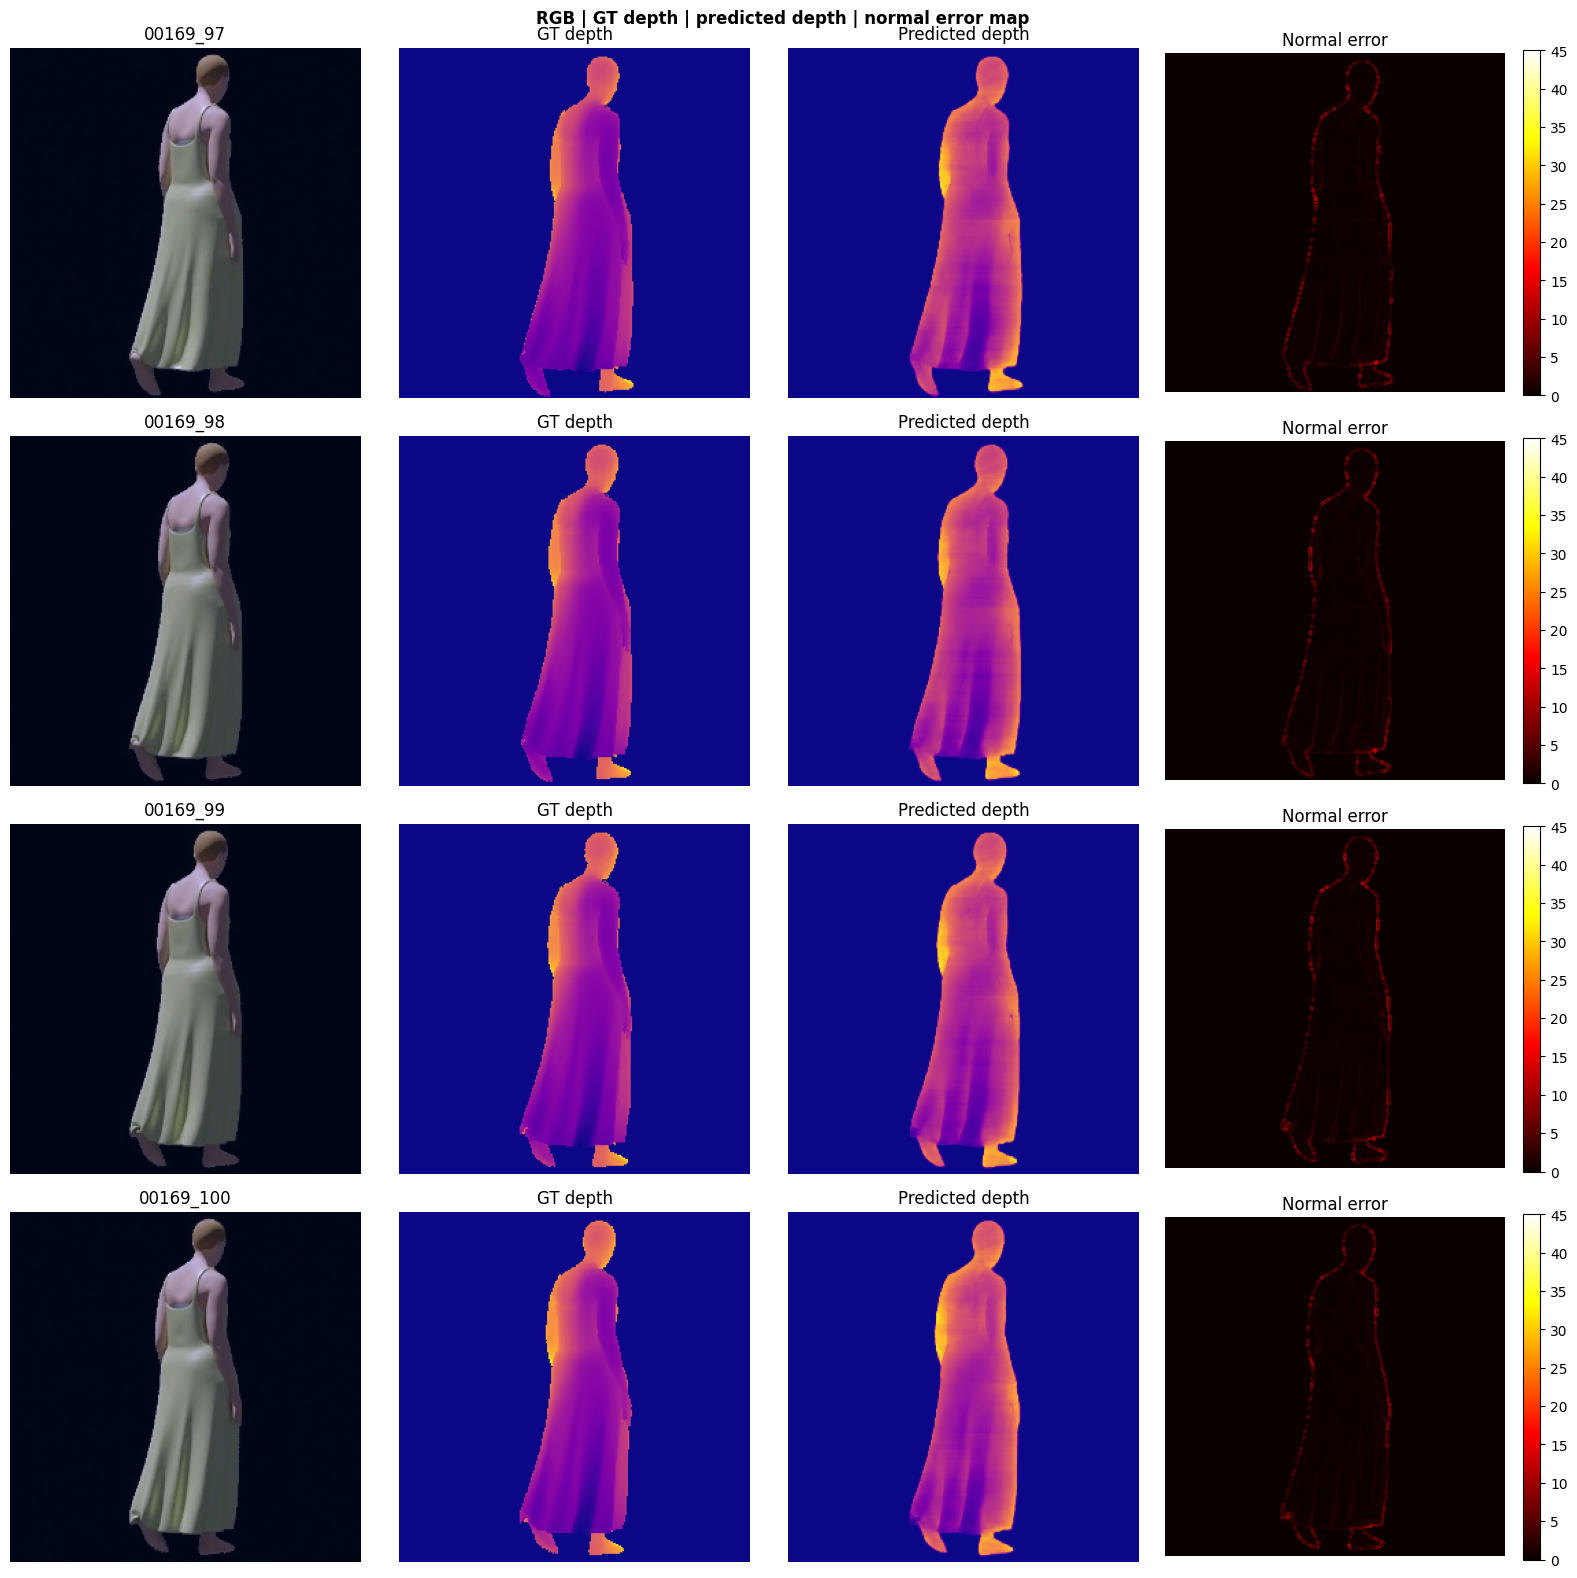

Saved: C:\Users\Daniel Hess\Documents\Master\OR\Pose_Estimation\runs\d1_unet\figures\predictions_256_nearest_no_aug_lr1e_3_bs8.png


In [15]:
@torch.no_grad()
def visualize_predictions(result, n_samples=4):
    cfg = build_cfg(result['label'], result)
    model = UNet().to(DEVICE)
    model.load_state_dict(torch.load(result['checkpoint'], map_location=DEVICE, weights_only=True))
    model.eval()
    ds = Cloth3DDataset(test_list, cfg['root'], img_size=cfg['img_size'], augment=False, cfg=cfg)

    n_samples = min(n_samples, len(ds))
    fig, axes = plt.subplots(n_samples, 4, figsize=(16, 4 * n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]
    fig.suptitle('RGB | GT depth | predicted depth | normal error map', fontweight='bold')

    for i in range(n_samples):
        X, Y = ds[i]
        pred = model(X.unsqueeze(0).to(DEVICE)).cpu().squeeze(0)

        rgb = X.permute(1, 2, 0).numpy()
        rgb = (rgb - rgb.min()) / (rgb.max() - rgb.min() + 1e-5)
        gt_np = Y.squeeze().numpy()
        pred_np = pred.squeeze().numpy()

        n_pred = depth_to_normals(pred.unsqueeze(0))
        n_gt = depth_to_normals(Y.unsqueeze(0))
        cos_s = (n_pred * n_gt).sum(dim=1).clamp(-1.0, 1.0)
        err_map = (torch.acos(cos_s) * 180.0 / torch.pi).squeeze().numpy()

        axes[i, 0].imshow(rgb); axes[i, 0].set_title(test_list[i])
        axes[i, 1].imshow(gt_np, cmap='plasma'); axes[i, 1].set_title('GT depth')
        axes[i, 2].imshow(pred_np, cmap='plasma'); axes[i, 2].set_title('Predicted depth')
        im = axes[i, 3].imshow(err_map, cmap='hot', vmin=0, vmax=45); axes[i, 3].set_title('Normal error')
        plt.colorbar(im, ax=axes[i, 3], fraction=0.046)
        for ax in axes[i]:
            ax.axis('off')

    plt.tight_layout()
    out_path = FIG_ROOT / f'predictions_{slugify(result["label"])}.png'
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f'Saved: {out_path}')


visualize_predictions(best_result, n_samples=4)
cleanup_cuda()


## 12 - Discussion Notes

### What makes monocular depth estimation ill-posed?

Monocular depth estimation is ill-posed because a single RGB image is only a 2D projection of a 3D scene. Many different 3D configurations can produce almost the same image: a small nearby object can look like a larger object farther away, absolute scale is ambiguous, and texture or shading can be misleading. Unlike stereo or depth sensors, a monocular image does not provide direct geometric disparity. The network therefore learns statistical cues such as body silhouette, pose, clothing folds, perspective, shading, and typical human shape, but these cues do not uniquely determine depth.

### Interpolation: nearest vs bilinear

The first decision was the depth resizing method, because this preprocessing choice affects every later experiment. Nearest-neighbour resizing clearly won. With full augmentation at 256 px, nearest achieved validation RMSE `0.0929`, test RMSE `0.0678`, and normal MAE `1.42 deg`. Bilinear resizing failed badly, with validation RMSE `1.4431`, test RMSE `1.3349`, and normal MAE `5.40 deg`.

This is consistent with the expected boundary problem for depth maps. The background is encoded as zero, so bilinear interpolation mixes foreground depth values with zero background values around silhouettes and thin regions. That creates invalid intermediate depths near object boundaries. Nearest-neighbour preserves the foreground/background separation better, so it was fixed for the remaining experiments.

### Augmentation ablation

Using nearest-neighbour depth resizing at 256 px, the best augmentation setting was no augmentation. The no-augmentation model reached validation RMSE `0.0889`, test RMSE `0.0660`, and normal MAE `1.13 deg`. The augmented variants were worse: flip+scale reached validation RMSE `0.0932`, flip+shift+scale+rotation reached `0.0945`, and full augmentation including shear reached `0.0929`.

This suggests that the preprocessed CLOTH3D++ crops already contain enough pose and appearance variation, and that additional geometric transforms can hurt dense depth supervision. Rotation, shift, scale/crop, and especially shear may create image-depth pairs that are less physically consistent with the original camera geometry. For this dataset and 8-epoch training budget, preserving the original cropped geometry generalized better than aggressive augmentation.

### Learning rate vs batch size

With nearest interpolation and no augmentation fixed, the best validation result was `lr=1e-3, batch_size=8`, with validation RMSE `0.0889`. The smaller batch `lr=1e-3, batch_size=4` was close, with validation RMSE `0.0900`, and had the best normal MAE among the LR/batch runs (`1.13 deg`) plus slightly lower test RMSE (`0.0652`). The lower learning rate `lr=1e-4, batch_size=8` had the best test RMSE (`0.0639`) but worse validation RMSE (`0.0913`). The larger batch `lr=1e-3, batch_size=16` was worse, with validation RMSE `0.0931`.

Since model selection was based on validation RMSE, `lr=1e-3, batch_size=8` was selected for the final resolution comparison. The results indicate that lowering the learning rate made optimization more conservative and may have improved test RMSE, but it did not win on the validation criterion. Larger batch size did not help here, possibly because it reduced gradient noise too much or provided fewer updates per epoch.

### Resolution: 256 vs 384

The final resolution comparison used the selected pipeline: nearest-neighbour interpolation, no augmentation, `lr=1e-3`, and batch size 8. At 256 px, the model achieved validation RMSE `0.0889`, test RMSE `0.0660`, normal MAE `1.13 deg`, and about `179.7 FPS`. At 384 px, the model achieved validation RMSE `0.0943`, test RMSE `0.0673`, normal MAE `0.93 deg`, and about `74.1 FPS`.

Thus, 384 px improved the normal angular error, which makes sense because higher resolution preserves finer local depth gradients. However, it did not improve RMSE, and it was much slower. Under the chosen selection criterion, 256 px is the better final setting because it gives lower validation/test RMSE and substantially higher FPS. The 384 px result is still useful qualitatively: it may produce smoother or more spatially detailed surface normals, but the accuracy/speed tradeoff is not favorable for this baseline.

### Was the comparison fair?

The 256 vs 384 comparison is mostly fair because both resolutions used the same selected preprocessing, augmentation policy, learning rate, batch size, architecture, train/validation/test split, and epoch budget. The main caveat is that 384 px might have its own optimal hyperparameters. For example, a different learning rate, batch size, or longer training schedule might improve 384 px. We did not tune those separately because the assignment asks for comparison rather than exhaustive grid search, and 384 px is the most expensive axis.

The interpolation comparison is also defensible because bilinear performed dramatically worse under the same full-augmentation baseline, so it is unlikely that later tuning would reverse the conclusion. Still, strictly speaking, bilinear was not re-tested under the final no-augmentation setting. The augmentation and LR/batch comparisons are fair within the chosen 8-epoch budget, but additional epochs could change convergence-based conclusions.

One caution is GPU memory: the recorded memory numbers should be interpreted carefully because cached runs and PyTorch peak-memory tracking can include retained allocations depending on when measurement occurs. FPS, RMSE, and normal MAE are more directly comparable here. For the written report, the strongest conclusion is therefore based on accuracy and speed: nearest interpolation, no augmentation, `lr=1e-3`, `batch_size=8`, and 256 px is the most defensible final baseline configuration.